# Mean-centred ERP analysis

This example will show how to use mean-centred PLS for analyzing ERP data. We will use the MNE example data, in which a single participant viewed visual stimuli presented to the left or right visual field, or heard auditory stimuli presented to the left or right ear. Following the MNE example [here](https://mne.tools/stable/auto_tutorials/evoked/30_eeg_erp.html), we will compare the left visual and auditory stimuli.

## Loading the data

We will begin by loading the necessary libraries and epoching the data. The details of creating epochs are covered in the MNE example.

In [19]:
import mne
import mne_plsc
import pandas as pd

sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"
raw = mne.io.read_raw_fif(sample_data_raw_file)
events = mne.find_events(raw, stim_channel="STI 014")
raw.pick(["eeg", "eog"]).load_data()
raw.crop(tmax=90)
events = events[events[:, 0] <= raw.last_samp]
event_dict = {
    "auditory/left": 1,
    "visual/left": 3,
}
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_dict,
    tmin=-0.2, tmax=0.5,
    preload=True
)
reject_criteria = dict(eog=200e-6)
epochs = epochs.drop_bad(reject=reject_criteria)
epochs = epochs.pick('eeg')

Opening raw data file C:\Users\isaac\mne_data\MNE-sample-data\MEG\sample\sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
Finding events on: STI 014
319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Reading 0 ... 41699  =      0.000 ...   277.709 secs...
Not setting metadata
61 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 61 events and 106 original time points ...
1 bad epochs dropped
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
3 bad epochs dropped


## Fitting the model

To fit the model, we need to first determine which epochs are from which condition. To do so, we can use the `get_epoch_labels` function from `mne_plsc.utils`:

In [20]:
labels = mne_plsc.utils.get_epoch_labels(epochs)

For within-subject trial-level analysis, condition labels have to be 

In [21]:
epochs.metadata = pd.DataFrame({'cond': labels})
epochs.metadata.head()

Adding metadata with 1 columns


,cond
1,visual/left
2,auditory/left
5,visual/left
6,auditory/left
9,visual/left


Next, we can fit a model to the data and visualize it.

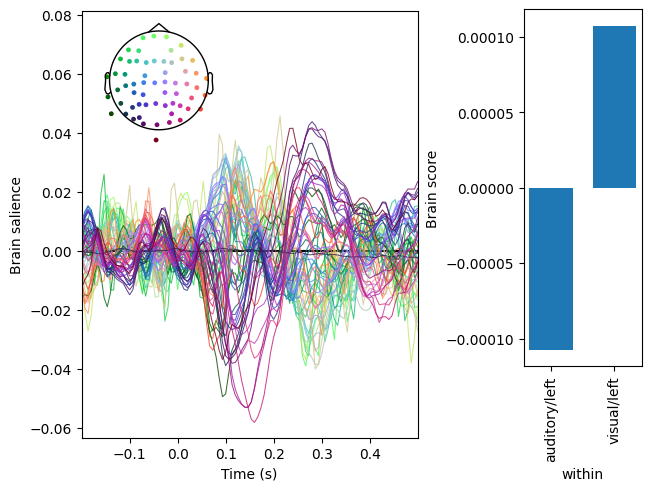

In [28]:
res = mne_plsc.fit_mc([epochs], obs_level='trial', within='cond', random_state=123)
res.plot_lv(0);

In the plot above, the right panel displays a multivariate pattern of activity that differentiates between the conditions. The left panel indicates how strongly the pattern is expressed in each condition.

## Assessing model significance

To assess the significance of the model, we can run permutation testing. For speed, we will only do 100 permutations here. For real data, it is advisable to do many more.

permuting: 100%|████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 417.62it/s]


   LV index  singular value  variance explained   p value
0         0        0.000152                 1.0  0.009901
1         1        0.000000                 0.0       NaN


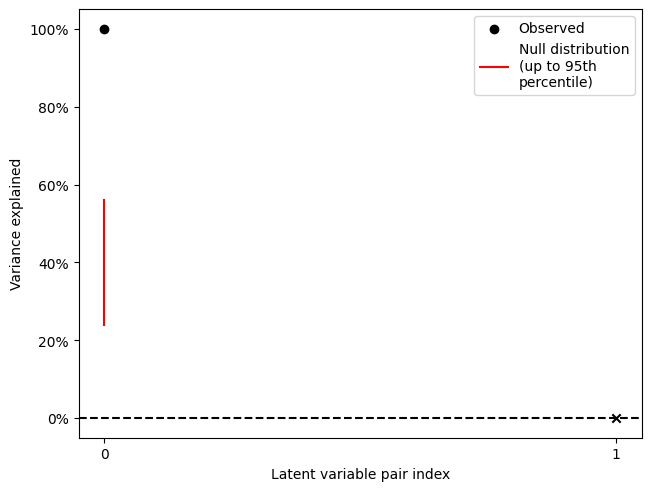

In [23]:
res.permute(100)
print(res.summary())
res.plot_scree()

Thus, the comparison between auditory and visual stimuli is significant. Note that although the decomposition yields 2 latent variable pairs, the second $p$ value is NA (corresponding to the "x" on the scree plot). This is because the rank of the decomposed matrix is one for this mean-centred analysis due to the mean-centering step.

## Cluster analysis

To characterize the latent variable pair, we can run bootstrap resampling and cluster the $z$ scores. For speed, we will run 100 resamples; for real data, it would be advisable to do many more.

In [24]:
res.bootstrap(100)

Resampling: 100%|███████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 193.75it/s]


Before cluster analysis, it is necessary to add an adjacency matrix to the data. In the case of ERP analysis, it generally makes sense to treat all channels as adjacent in order to detect multi-channel patterns. This is the default behaviour of `.add_adjacency()` but can be changed by setting `all_channels_adjacent=False`.

In [25]:
res.add_adjacency()
res.cluster(threshold=4, which='z-scores')

Defaulting to all channels adjacent for ERP/ERF analysis
Defaulting to unsigned clustering
Computing clusters for lv_idx 0...
Threshold: 4
3 clusters


Plotting the cluster sizes shows us that, of the three clusters, only two account for a major proportion of the strong saliences:

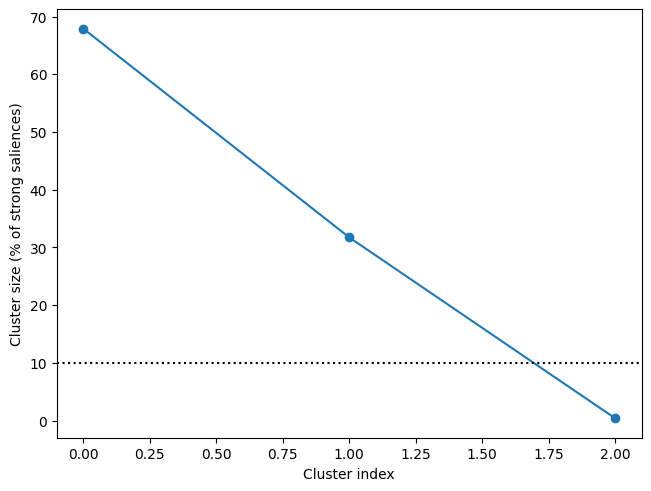

In [26]:
f, ax = res.plot_cluster_sizes(lv_idx=0)
ax.axhline(y=10, c='k', ls=':')

We can plot both of them using the `.plot_clusters()` method. Note the similarity of the topomaps here to those in the [MNE tutorial](https://mne.tools/stable/auto_tutorials/evoked/30_eeg_erp.html#comparing-conditions).

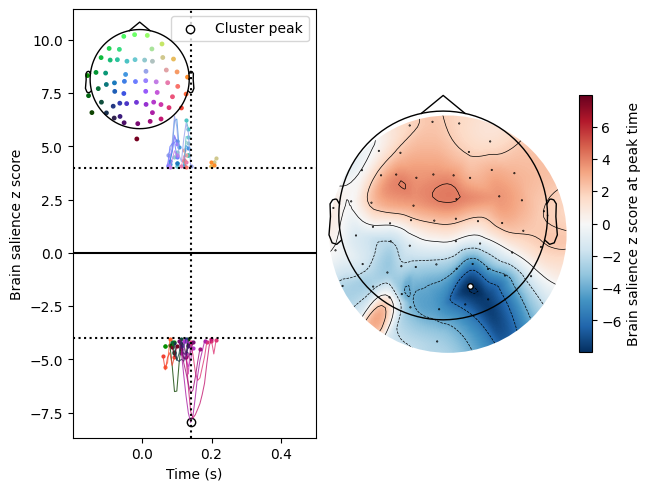

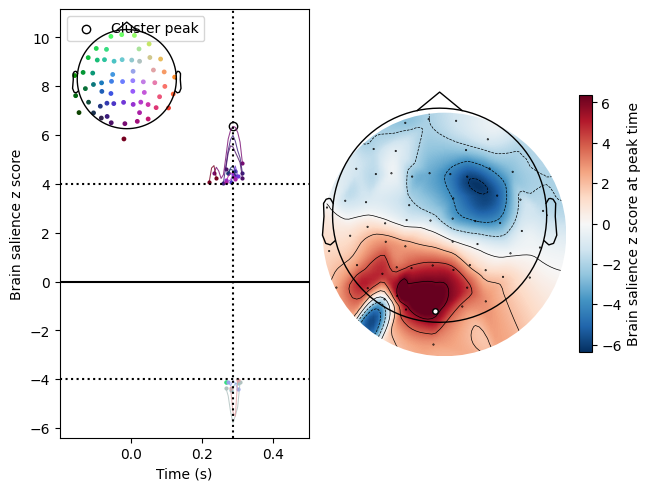

In [27]:
res.plot_cluster(lv_idx=0, cluster_idx=0);
res.plot_cluster(lv_idx=0, cluster_idx=1);

Note also that both positive and negative saliences can be included in the same cluster. This is the default setting for clustering ERP/ERF data, since positive and negative deflections are often considered part of the same component when they occur simultaneously. This can be adjusted using the `signed` argument to `cluster()`: with `signed=True`, positive and negative saliences cannot be part of the same cluster.